1. Cài đặt & import thư viện

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)
np.random.seed(42)

2. Nạp dữ liệu & Data Cleaning

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving trang_suc_processed_full.csv to trang_suc_processed_full (4).csv


In [ ]:
CSV_PATH = "trang_suc_processed_full.csv"  # đổi lại đường dẫn nếu cần
df = pd.read_csv(CSV_PATH)
print("Kích thước dữ liệu:", df.shape)
df.head()

Kích thước dữ liệu: (3593, 30)


,customer_id,age,gender,province,region,jewelry_category,material,karat_purity,weight_grams,has_gemstone,...,previous_purchases,frequency_of_purchases,recency_proxy_days,monetary_est_vnd,clv_est_vnd,next_period_spend_est_vnd,churn,cluster,cluster_name,churn_proba
0,1,22,Nữ,TP. Hồ Chí Minh,Miền Nam,Lắc chân,Bạc,5,9.59,0,...,1,Hàng quý,96.0,142000.0,146232.0,241372.0,0,0,Khách hàng phổ thông / mới,0.164305
1,2,55,Nữ,Thái Nguyên,Miền Bắc,Dây chuyền,Vàng đính đá quý,18,3.82,1,...,20,Hàng năm,337.0,40188000.0,36346027.0,872132.0,1,2,Khách hàng có nguy cơ rời bỏ,0.764052
2,3,49,Nam,Nghệ An,Miền Trung,Vòng tay,Vàng đính đá quý,18,5.57,1,...,28,Hàng tuần,8.0,75656000.0,74029396.0,45255147.0,0,3,Khách hàng trung thành,0.384698
3,4,39,Nữ,Bắc Ninh,Miền Bắc,Nhẫn,Vàng 24K,24,6.15,0,...,2,Hàng năm,339.0,5100000.0,5865000.0,1437755.0,0,2,Khách hàng có nguy cơ rời bỏ,0.169330
4,5,38,Nữ,Bình Định,Miền Trung,Nhẫn,Vàng 24K,24,5.61,0,...,19,Hàng quý,95.0,48480000.0,55417488.0,3859036.0,0,3,Khách hàng trung thành,0.273453


In [ ]:
# --- Kiểm tra Data Cleaning ---
print("Số giá trị thiếu theo từng cột:")
print(df.isnull().sum())
print("\nSố bản ghi trùng lặp (toàn bộ dòng):", df.duplicated().sum())
print("Số bản ghi trùng lặp theo customer_id:", df.duplicated(subset=['customer_id']).sum())

def iqr_outliers(s):
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((s < lo) | (s > hi)).sum()

print("\nSố ngoại lệ (IQR) - purchase_amount_vnd:", iqr_outliers(df['purchase_amount_vnd']))
print("Số ngoại lệ (IQR) - weight_grams:", iqr_outliers(df['weight_grams']))
print("Số ngoại lệ (IQR) - previous_purchases:", iqr_outliers(df['previous_purchases']))

Số giá trị thiếu theo từng cột:
customer_id                     0
age                             0
gender                          0
province                        0
region                          0
jewelry_category                0
material                        0
karat_purity                    0
weight_grams                    0
has_gemstone                    0
occasion                        0
purchase_amount_vnd             0
estimated_monthly_income_vnd    0
review_rating                   0
membership_status               0
discount_applied                0
promo_code_used                 0
payment_method                  0
shipping_type                   0
purchase_channel                0
previous_purchases              0
frequency_of_purchases          0
recency_proxy_days              0
monetary_est_vnd                0
clv_est_vnd                     0
next_period_spend_est_vnd       0
churn                           0
cluster                         0
cluster_name    

3. Xây dựng biến kỹ thuật (Feature Engineering)

In [ ]:
# --- clv_est_vnd: điều chỉnh monetary_est_vnd theo review_rating và membership_status ---
rating_factor = 1 + (df['review_rating'] - 3.5) * 0.06
member_factor = np.where(df['membership_status'] == 'Có', 1.15, 0.95)
df['clv_est_vnd'] = (df['monetary_est_vnd'] * rating_factor * member_factor).round(0)

# --- next_period_spend_est_vnd: suy ra từ purchase_amount & tần suất mua ước tính, có nhiễu ngẫu nhiên ---
implied_freq = (30 / df['recency_proxy_days'].replace(0, 1)).clip(upper=3)
noise = np.random.normal(1.0, 0.18, size=len(df))
df['next_period_spend_est_vnd'] = (df['purchase_amount_vnd'] * implied_freq * noise).round(0)

# --- churn: nhãn rule-based ---
score = np.zeros(len(df))
score += df['frequency_of_purchases'].isin(['Hàng năm', 'Nửa năm một lần']).astype(int) * 2
score += (df['membership_status'] == 'Không').astype(int)
score += (df['review_rating'] < 3.5).astype(int)
score += (df['promo_code_used'] == 'Không').astype(int)
score += (df['discount_applied'] == 'Không').astype(int)
score -= df['frequency_of_purchases'].isin(['Hàng tuần', 'Hai tuần một lần']).astype(int)
rand_noise = np.random.normal(0, 0.9, size=len(df))
df['churn'] = ((score + rand_noise) >= 4.2).astype(int)

print("Tỷ lệ churn:", round(df['churn'].mean()*100, 1), "%")
df[['clv_est_vnd', 'next_period_spend_est_vnd', 'churn']].describe()


Tỷ lệ churn: 26.0 %


,clv_est_vnd,next_period_spend_est_vnd,churn
count,3.593000e+03,3.593000e+03,3593.000000
mean,3.969487e+07,8.521998e+06,0.260228
std,4.811485e+07,1.715235e+07,0.438820
min,5.631600e+04,1.324700e+04,0.000000
25%,5.165418e+06,7.574510e+05,0.000000
50%,2.348210e+07,2.531163e+06,0.000000
75%,5.498529e+07,8.266718e+06,1.000000
max,4.285903e+08,1.824270e+08,1.000000


4. Phân tích khám phá dữ liệu (EDA)

In [ ]:
num_cols = ['age','weight_grams','purchase_amount_vnd','previous_purchases','review_rating','monetary_est_vnd','clv_est_vnd']
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,3593.0,4.152213e+01,1.387442e+01,18.00,29.00,41.00,54.00,6.500000e+01
weight_grams,3593.0,8.624336e+00,6.557627e+00,1.01,4.18,6.46,11.38,3.494000e+01
purchase_amount_vnd,3593.0,1.271415e+07,1.225705e+07,300000.00,3598000.00,9826000.00,17978000.00,7.532600e+07
previous_purchases,3593.0,1.548372e+01,8.722735e+00,1.00,8.00,16.00,23.00,3.000000e+01
review_rating,3593.0,3.768912e+00,7.236726e-01,2.50,3.10,3.80,4.40,5.000000e+00
monetary_est_vnd,3593.0,3.874159e+07,4.703599e+07,60000.00,5085000.00,23097000.00,53345000.00,3.682680e+08
clv_est_vnd,3593.0,3.969487e+07,4.811485e+07,56316.00,5165418.00,23482100.00,54985286.00,4.285903e+08


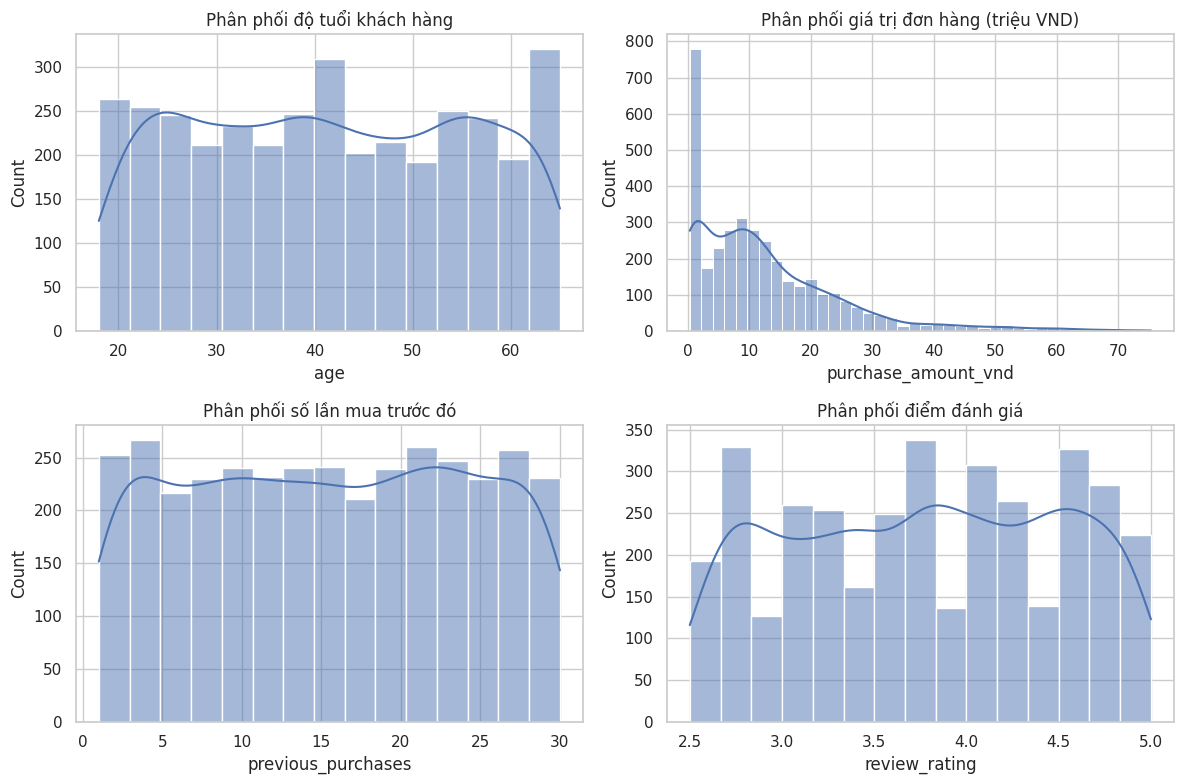

In [ ]:
# Hình 2: phân phối các biến định lượng chính
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df['age'], kde=True, ax=axes[0,0]); axes[0,0].set_title("Phân phối độ tuổi khách hàng")
sns.histplot(df['purchase_amount_vnd']/1e6, kde=True, ax=axes[0,1]); axes[0,1].set_title("Phân phối giá trị đơn hàng (triệu VND)")
sns.histplot(df['previous_purchases'], kde=True, ax=axes[1,0]); axes[1,0].set_title("Phân phối số lần mua trước đó")
sns.histplot(df['review_rating'], kde=True, ax=axes[1,1]); axes[1,1].set_title("Phân phối điểm đánh giá")
plt.tight_layout(); plt.show()


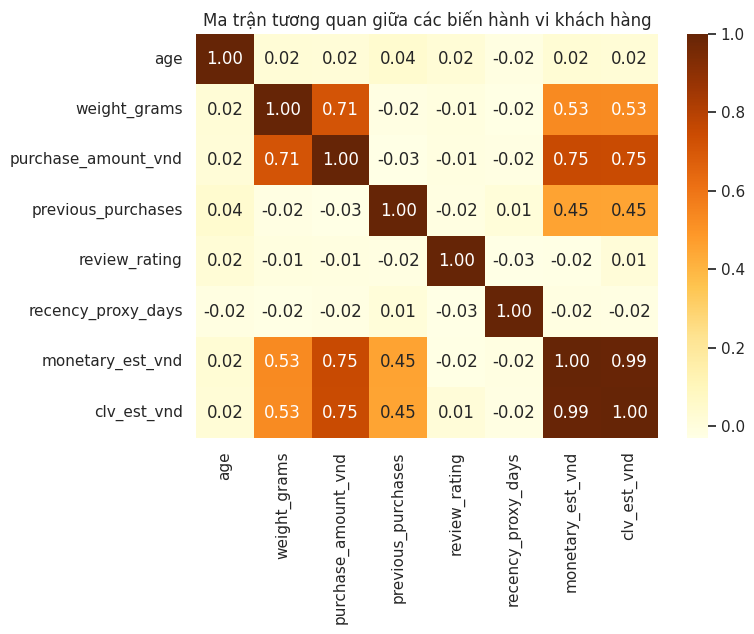

In [ ]:
# Hình 3: ma trận tương quan
corr_cols = ['age','weight_grams','purchase_amount_vnd','previous_purchases','review_rating','recency_proxy_days','monetary_est_vnd','clv_est_vnd']
corr = df[corr_cols].corr()
plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="YlOrBr")
plt.title("Ma trận tương quan giữa các biến hành vi khách hàng")
plt.tight_layout(); plt.show()

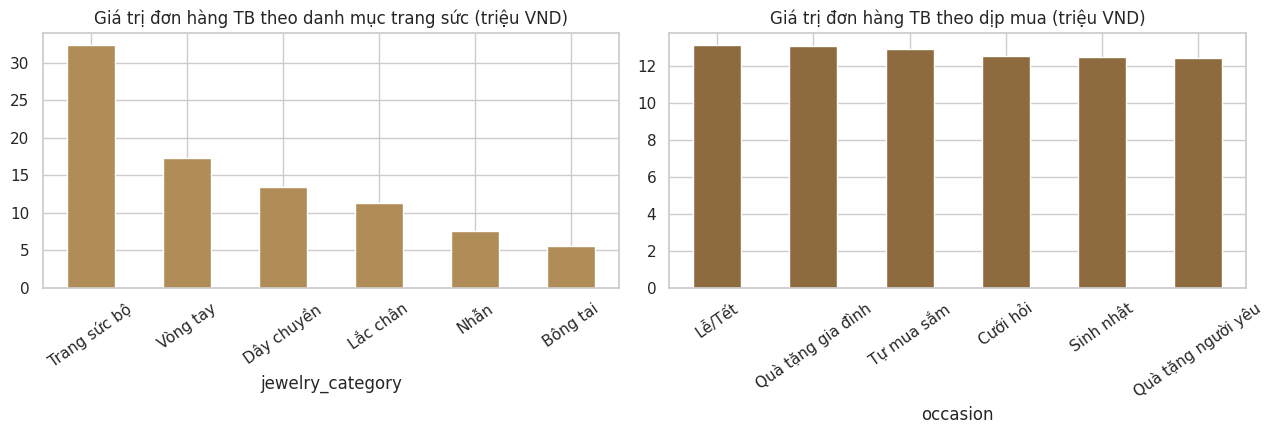

jewelry_category
Trang sức bộ    32419239.0
Vòng tay        17296869.0
Dây chuyền      13488155.0
Lắc chân        11297707.0
Nhẫn             7493683.0
Bông tai         5606433.0
Name: purchase_amount_vnd, dtype: float64
occasion
Lễ/Tết                13133458.0
Quà tặng gia đình     13057572.0
Tự mua sắm            12927315.0
Cưới hỏi              12551956.0
Sinh nhật             12457390.0
Quà tặng người yêu    12443351.0
Name: purchase_amount_vnd, dtype: float64


In [ ]:
# Hình 4: giá trị đơn hàng trung bình theo danh mục & dịp mua
cat_avg = df.groupby('jewelry_category')['purchase_amount_vnd'].mean().sort_values(ascending=False)
occasion_avg = df.groupby('occasion')['purchase_amount_vnd'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
(cat_avg/1e6).plot(kind='bar', ax=axes[0], color="#b08d57")
axes[0].set_title("Giá trị đơn hàng TB theo danh mục trang sức (triệu VND)"); axes[0].tick_params(axis='x', rotation=35)
(occasion_avg/1e6).plot(kind='bar', ax=axes[1], color="#8e6b3f")
axes[1].set_title("Giá trị đơn hàng TB theo dịp mua (triệu VND)"); axes[1].tick_params(axis='x', rotation=35)
plt.tight_layout(); plt.show()

print(cat_avg.round(0))
print(occasion_avg.round(0))

5. Dashboard tổng quan khách hàng

In [ ]:
total_customers = len(df)
total_monetary = df['monetary_est_vnd'].sum()
avg_clv = df['clv_est_vnd'].mean()
churn_rate = df['churn'].mean()
churn_by_region = df.groupby('region')['churn'].mean().sort_index()
gender_spend_share = df.groupby('gender')['monetary_est_vnd'].sum()
gender_spend_share = gender_spend_share / gender_spend_share.sum() * 100
membership_rate = (df['membership_status'] == 'Có').mean()

print(f"Tổng khách hàng: {total_customers:,}")
print(f"Tổng chi tiêu ước tính: {total_monetary/1e9:.1f} tỷ VND")
print(f"CLV trung bình: {avg_clv/1e6:.1f} triệu VND/khách")
print(f"Tỷ lệ churn: {churn_rate*100:.1f}%")
print(f"Tỷ lệ đăng ký thành viên: {membership_rate*100:.1f}%")
print("\nTỷ lệ churn theo miền:\n", (churn_by_region*100).round(1))
print("\nCơ cấu chi tiêu theo giới tính (%):\n", gender_spend_share.round(1))

Tổng khách hàng: 3,593
Tổng chi tiêu ước tính: 139.2 tỷ VND
CLV trung bình: 39.7 triệu VND/khách
Tỷ lệ churn: 26.0%
Tỷ lệ đăng ký thành viên: 30.3%

Tỷ lệ churn theo miền:
 region
Miền Bắc      25.3
Miền Nam      25.8
Miền Trung    27.1
Name: churn, dtype: float64

Cơ cấu chi tiêu theo giới tính (%):
 gender
Nam    28.9
Nữ     71.1
Name: monetary_est_vnd, dtype: float64


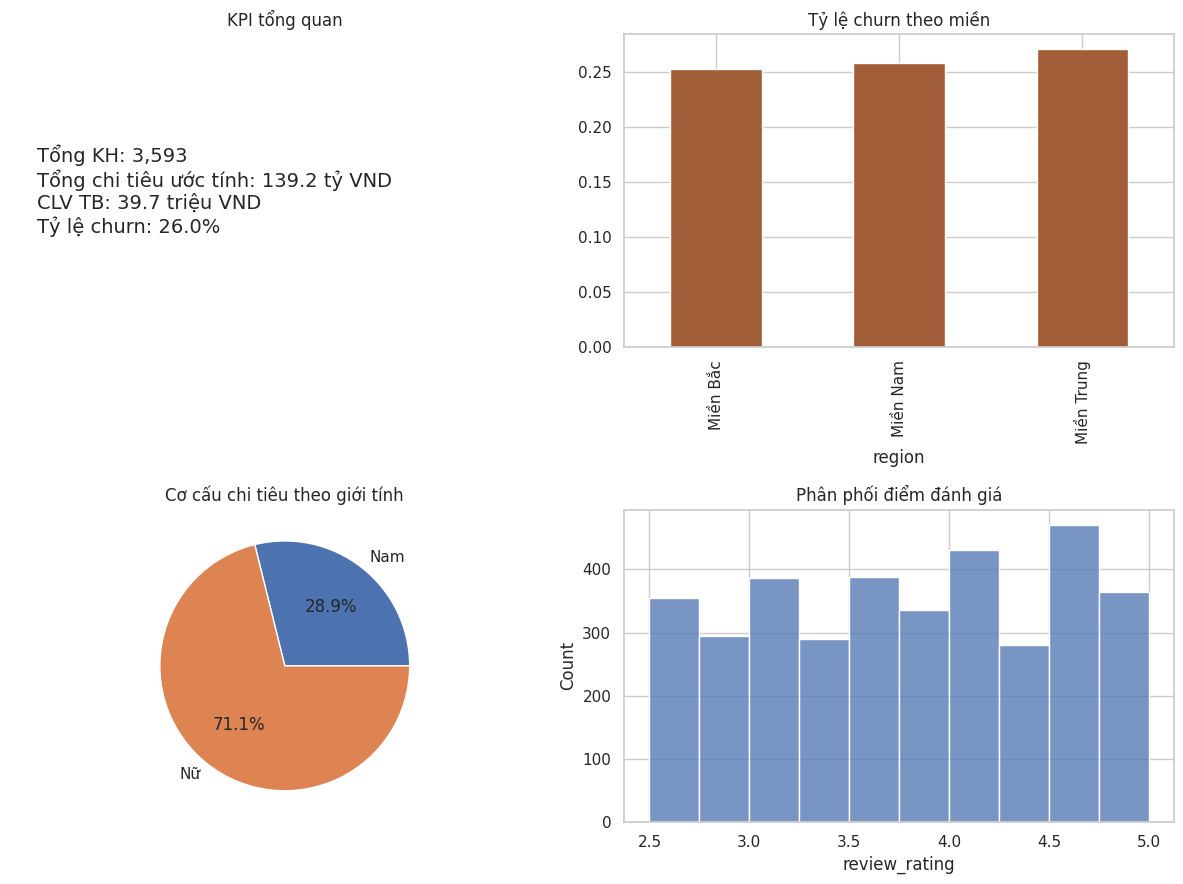

In [ ]:
# Dashboard: KPI + churn theo miền + cơ cấu giới tính + phân phối rating
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
kpi_text = (f"Tổng KH: {total_customers:,}\n"
            f"Tổng chi tiêu ước tính: {total_monetary/1e9:.1f} tỷ VND\n"
            f"CLV TB: {avg_clv/1e6:.1f} triệu VND\n"
            f"Tỷ lệ churn: {churn_rate*100:.1f}%")
axes[0,0].axis('off'); axes[0,0].text(0.05, 0.5, kpi_text, fontsize=14, va='center'); axes[0,0].set_title("KPI tổng quan")
churn_by_region.plot(kind='bar', ax=axes[0,1], color="#a15c38"); axes[0,1].set_title("Tỷ lệ churn theo miền")
gender_spend_share.plot(kind='pie', ax=axes[1,0], autopct='%1.1f%%'); axes[1,0].set_ylabel(""); axes[1,0].set_title("Cơ cấu chi tiêu theo giới tính")
sns.histplot(df['review_rating'], bins=10, ax=axes[1,1]); axes[1,1].set_title("Phân phối điểm đánh giá")
plt.tight_layout(); plt.show()


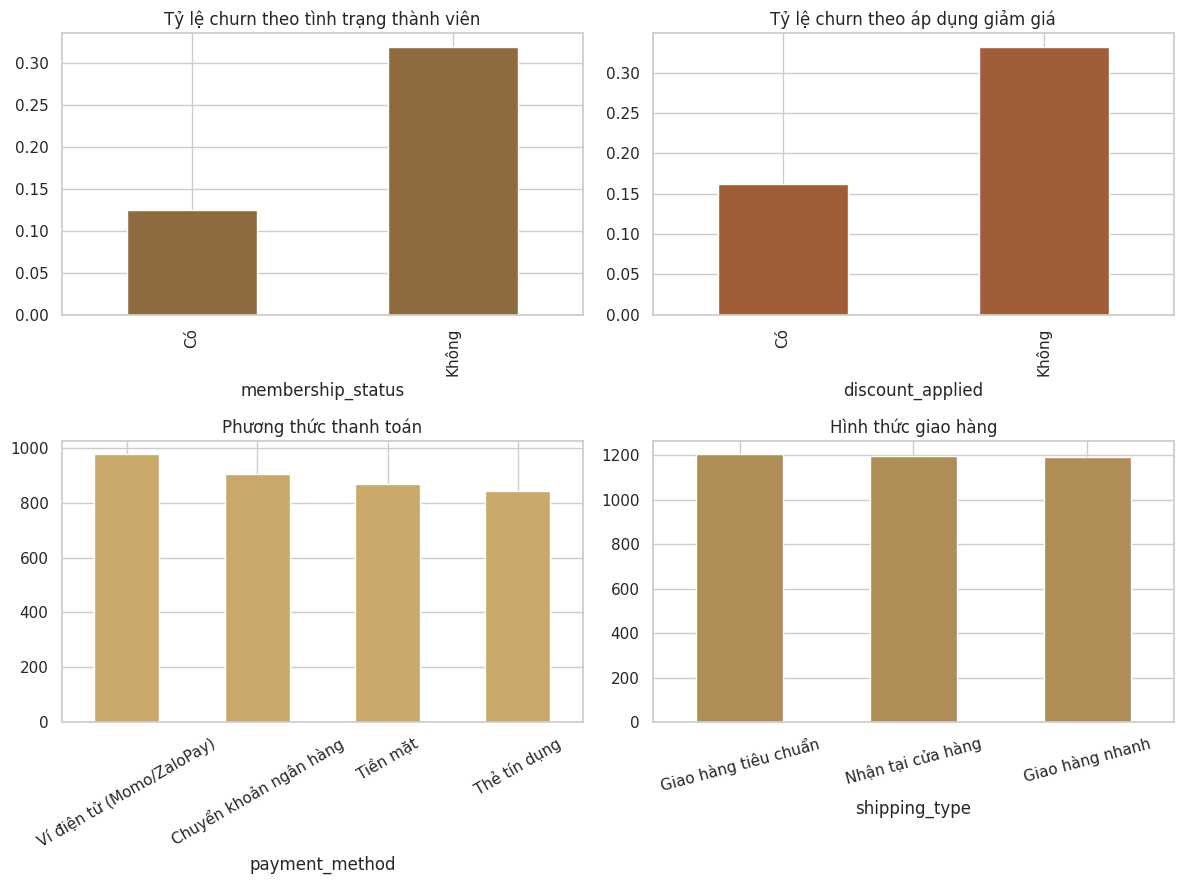

Churn theo thành viên (%):
 membership_status
Có       12.5
Không    31.9
Name: churn, dtype: float64

Churn theo giảm giá (%):
 discount_applied
Có       16.2
Không    33.2
Name: churn, dtype: float64


In [ ]:
# Dashboard: hành vi & dịch vụ
churn_by_membership = df.groupby('membership_status')['churn'].mean()
churn_by_discount = df.groupby('discount_applied')['churn'].mean()

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
churn_by_membership.plot(kind='bar', ax=axes[0,0], color="#8e6b3f"); axes[0,0].set_title("Tỷ lệ churn theo tình trạng thành viên")
churn_by_discount.plot(kind='bar', ax=axes[0,1], color="#a15c38"); axes[0,1].set_title("Tỷ lệ churn theo áp dụng giảm giá")
df['payment_method'].value_counts().plot(kind='bar', ax=axes[1,0], color="#c9a86a"); axes[1,0].set_title("Phương thức thanh toán"); axes[1,0].tick_params(axis='x', rotation=30)
df['shipping_type'].value_counts().plot(kind='bar', ax=axes[1,1], color="#b08d57"); axes[1,1].set_title("Hình thức giao hàng"); axes[1,1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

print("Churn theo thành viên (%):\n", (churn_by_membership*100).round(1))
print("\nChurn theo giảm giá (%):\n", (churn_by_discount*100).round(1))


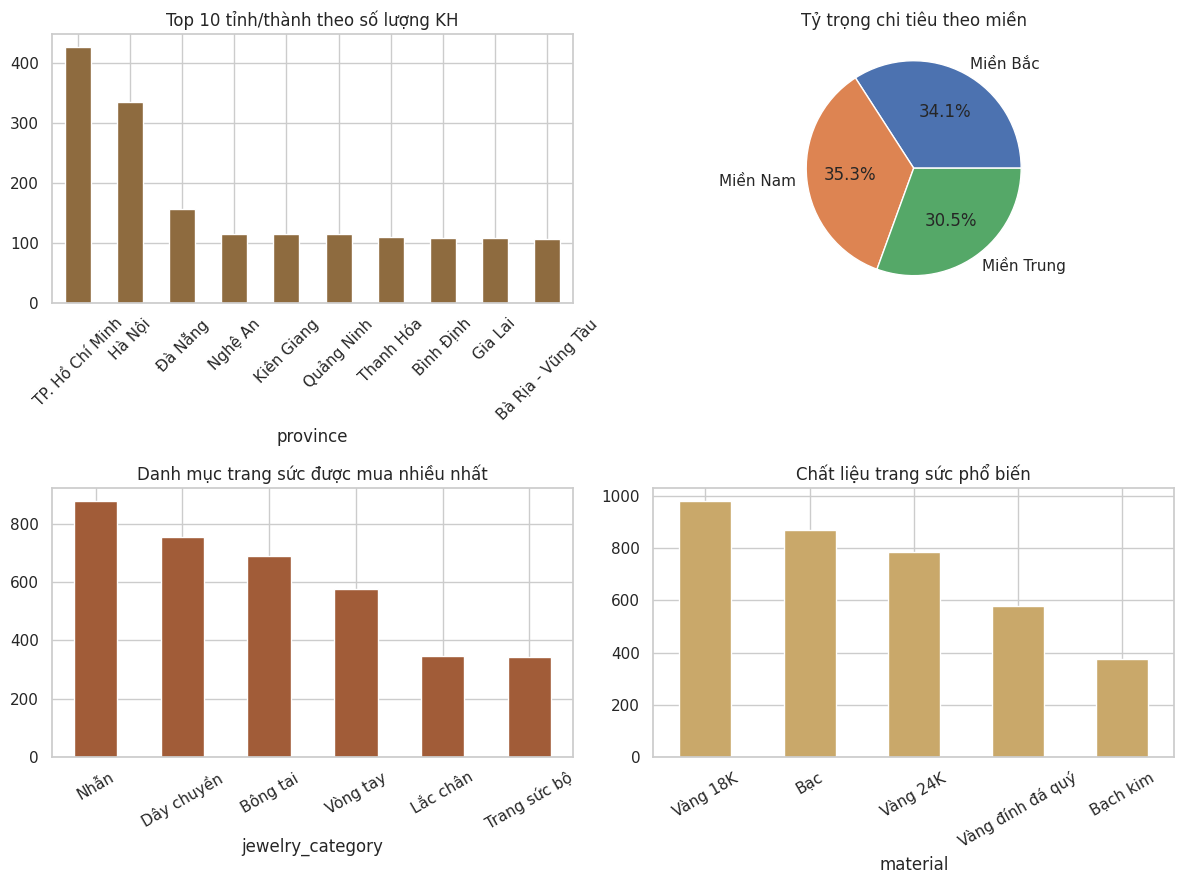

In [ ]:
# Dashboard: khu vực & sản phẩm
top_provinces = df['province'].value_counts().head(10)
region_spend_share = df.groupby('region')['monetary_est_vnd'].sum()
region_spend_share = region_spend_share / region_spend_share.sum() * 100

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
top_provinces.plot(kind='bar', ax=axes[0,0], color="#8e6b3f"); axes[0,0].set_title("Top 10 tỉnh/thành theo số lượng KH"); axes[0,0].tick_params(axis='x', rotation=45)
region_spend_share.plot(kind='pie', ax=axes[0,1], autopct='%1.1f%%'); axes[0,1].set_ylabel(""); axes[0,1].set_title("Tỷ trọng chi tiêu theo miền")
df['jewelry_category'].value_counts().plot(kind='bar', ax=axes[1,0], color="#a15c38"); axes[1,0].set_title("Danh mục trang sức được mua nhiều nhất"); axes[1,0].tick_params(axis='x', rotation=30)
df['material'].value_counts().plot(kind='bar', ax=axes[1,1], color="#c9a86a"); axes[1,1].set_title("Chất liệu trang sức phổ biến"); axes[1,1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

6. Phân cụm khách hàng (Clustering)

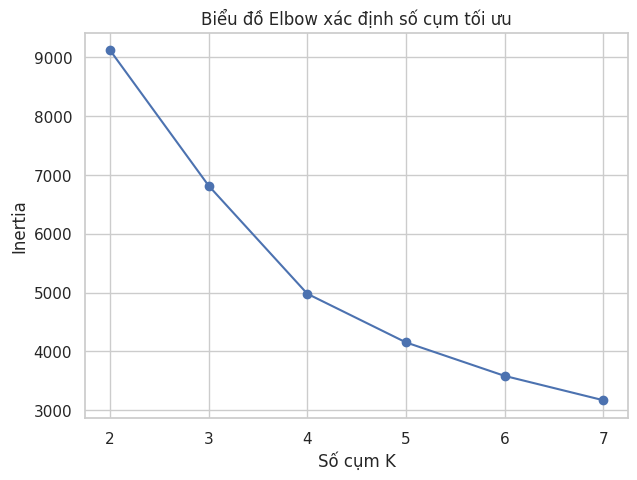

In [ ]:
rfm_cols = ['recency_proxy_days', 'previous_purchases', 'monetary_est_vnd', 'clv_est_vnd']
X_rfm = df[rfm_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_rfm)

inertias = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(list(K_range), inertias, marker='o')
plt.xlabel("Số cụm K"); plt.ylabel("Inertia"); plt.title("Biểu đồ Elbow xác định số cụm tối ưu")
plt.show()

In [ ]:
K_FINAL = 4
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

cluster_summary = df.groupby('cluster').agg(
    so_luong=('customer_id', 'count'),
    recency_tb=('recency_proxy_days', 'mean'),
    prev_purchases_tb=('previous_purchases', 'mean'),
    monetary_tb=('monetary_est_vnd', 'mean'),
    clv_tb=('clv_est_vnd', 'mean'),
).round(1)
cluster_summary['ty_le_%'] = (cluster_summary['so_luong'] / len(df) * 100).round(1)

# Gán nhãn nhóm theo đặc điểm: recency cao nhất -> nguy cơ rời bỏ; còn lại xếp theo CLV giảm dần
risk_cluster = cluster_summary['recency_tb'].idxmax()
remaining = [c for c in cluster_summary.index if c != risk_cluster]
remaining_sorted = cluster_summary.loc[remaining].sort_values('clv_tb', ascending=False).index.tolist()
label_map = {risk_cluster: "Khách hàng có nguy cơ rời bỏ"}
tags = ["Khách hàng VIP (giá trị cao nhất)", "Khách hàng trung thành", "Khách hàng phổ thông / mới"]
for c, t in zip(remaining_sorted, tags):
    label_map[c] = t
cluster_summary['nhom'] = cluster_summary.index.map(label_map)
df['cluster_name'] = df['cluster'].map(label_map)

cluster_summary.sort_values('clv_tb', ascending=False)


,so_luong,recency_tb,prev_purchases_tb,monetary_tb,clv_tb,ty_le_%,nhom
cluster,,,,,,,
1,399,145.0,23.6,144228248.1,147447962.7,11.1,Khách hàng VIP (giá trị cao nhất)
3,1233,89.7,21.8,38776480.1,39911824.3,34.3,Khách hàng trung thành
2,631,367.0,14.7,24634691.0,25228495.5,17.6,Khách hàng có nguy cơ rời bỏ
0,1330,88.4,7.6,13756079.7,14031193.5,37.0,Khách hàng phổ thông / mới


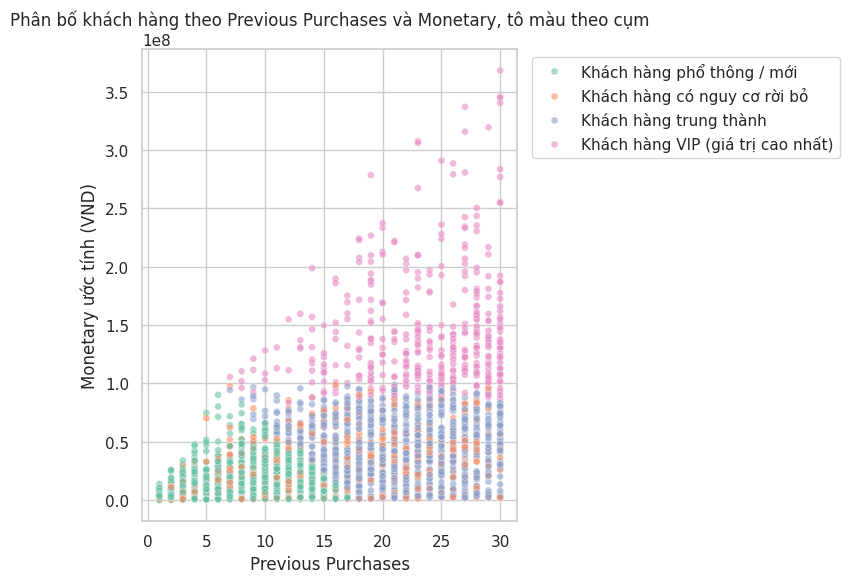

In [ ]:
# Hình 7: phân bố khách hàng theo Previous Purchases & Monetary, tô màu theo cụm
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='previous_purchases', y='monetary_est_vnd', hue='cluster_name', palette="Set2", alpha=0.6, s=25)
plt.ylabel("Monetary ước tính (VND)"); plt.xlabel("Previous Purchases")
plt.title("Phân bố khách hàng theo Previous Purchases và Monetary, tô màu theo cụm")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()


In [ ]:
# Câu hỏi kinh doanh 2: Top 5 khách hàng có CLV cao nhất
top5_vip = df.sort_values('clv_est_vnd', ascending=False).head(5)[['customer_id','clv_est_vnd','monetary_est_vnd','previous_purchases']]
top5_vip

,customer_id,clv_est_vnd,monetary_est_vnd,previous_purchases
2729,2736,428590298.0,368268000.0,30
14,15,358309923.0,346026000.0,30
836,840,345711565.0,315776000.0,27
121,122,334954754.0,340332000.0,30
2997,3004,328013414.0,278544000.0,19


7. Dự báo giá trị khách hàng (Linear Regression)

7.1. Mô hình A — Dự đoán CLV ước tính (`clv_est_vnd`)

In [ ]:
featA_num = ['age', 'purchase_amount_vnd', 'previous_purchases', 'review_rating']
featA_cat = ['jewelry_category', 'material', 'discount_applied', 'promo_code_used', 'membership_status', 'has_gemstone']
XA = pd.get_dummies(df[featA_num + featA_cat], columns=featA_cat, drop_first=True)
yA = df['clv_est_vnd']

XA_train, XA_test, yA_train, yA_test = train_test_split(XA, yA, test_size=0.2, random_state=42)
modelA = LinearRegression().fit(XA_train, yA_train)
predA = modelA.predict(XA_test)

r2_A = r2_score(yA_test, predA)
mae_A = mean_absolute_error(yA_test, predA)
print(f"R^2 = {r2_A:.3f}   MAE = {mae_A:,.0f} VND")

coefA = pd.Series(modelA.coef_, index=XA.columns).sort_values(key=abs, ascending=False)
print("\nTop hệ số hồi quy quan trọng nhất:")
print(coefA.head(8).round(0))

R^2 = 0.808   MAE = 13,649,347 VND

Top hệ số hồi quy quan trọng nhất:
membership_status_Không       -7213587.0
material_Vàng 18K              4371794.0
material_Vàng 24K              4276917.0
material_Bạch kim              3728926.0
material_Vàng đính đá quý      3011804.0
previous_purchases             2604598.0
jewelry_category_Dây chuyền    2510831.0
review_rating                  2212373.0
dtype: float64


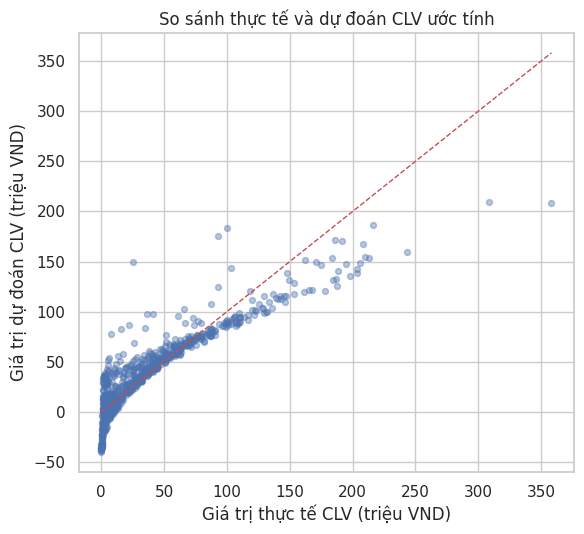

In [ ]:
plt.figure(figsize=(6, 5.5))
plt.scatter(yA_test/1e6, predA/1e6, alpha=0.4, s=18)
lims = [0, max(yA_test.max(), predA.max())/1e6]
plt.plot(lims, lims, 'r--', linewidth=1)
plt.xlabel("Giá trị thực tế CLV (triệu VND)"); plt.ylabel("Giá trị dự đoán CLV (triệu VND)")
plt.title("So sánh thực tế và dự đoán CLV ước tính")
plt.tight_layout(); plt.show()


7.2. Mô hình B — Dự đoán chi tiêu ước tính kỳ tiếp theo (`next_period_spend_est_vnd`)

In [ ]:
featB_num = ['age', 'purchase_amount_vnd', 'previous_purchases', 'review_rating']
featB_cat = ['jewelry_category', 'occasion', 'discount_applied', 'promo_code_used', 'membership_status']
XB = pd.get_dummies(df[featB_num + featB_cat], columns=featB_cat, drop_first=True)
yB = df['next_period_spend_est_vnd']

XB_train, XB_test, yB_train, yB_test = train_test_split(XB, yB, test_size=0.2, random_state=42)
modelB = LinearRegression().fit(XB_train, yB_train)
predB = modelB.predict(XB_test)

r2_B = r2_score(yB_test, predB)
mae_B = mean_absolute_error(yB_test, predB)
print(f"R^2 = {r2_B:.3f}   MAE = {mae_B:,.0f} VND")

coefB = pd.Series(modelB.coef_, index=XB.columns).sort_values(key=abs, ascending=False)
print("\nTop hệ số hồi quy quan trọng nhất:")
print(coefB.head(8).round(0))


R^2 = 0.252   MAE = 8,281,899 VND

Top hệ số hồi quy quan trọng nhất:
jewelry_category_Trang sức bộ    2856424.0
jewelry_category_Vòng tay        1600482.0
occasion_Quà tặng người yêu      1168792.0
occasion_Tự mua sắm               950662.0
review_rating                     719221.0
jewelry_category_Dây chuyền       692697.0
occasion_Quà tặng gia đình        590486.0
membership_status_Không           364073.0
dtype: float64


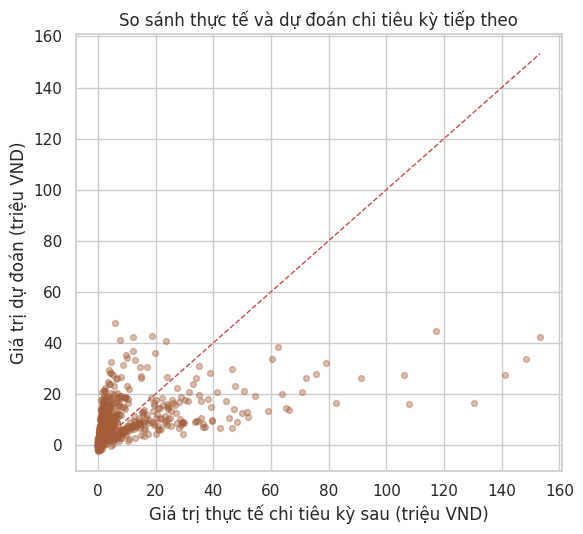

In [ ]:
plt.figure(figsize=(6, 5.5))
plt.scatter(yB_test/1e6, predB/1e6, alpha=0.4, s=18, color="#a15c38")
lims = [0, max(yB_test.max(), predB.max())/1e6]
plt.plot(lims, lims, 'r--', linewidth=1)
plt.xlabel("Giá trị thực tế chi tiêu kỳ sau (triệu VND)"); plt.ylabel("Giá trị dự đoán (triệu VND)")
plt.title("So sánh thực tế và dự đoán chi tiêu kỳ tiếp theo")
plt.tight_layout(); plt.show()


8. Dự đoán khách hàng rời bỏ (Classification)


In [ ]:
featC_num = ['age', 'purchase_amount_vnd', 'previous_purchases', 'review_rating', 'clv_est_vnd']
featC_cat = ['jewelry_category', 'material', 'occasion', 'payment_method', 'shipping_type',
             'discount_applied', 'promo_code_used', 'membership_status', 'gender', 'has_gemstone']
XC = pd.get_dummies(df[featC_num + featC_cat], columns=featC_cat, drop_first=True)
yC = df['churn']

XC_train, XC_test, yC_train, yC_test = train_test_split(XC, yC, test_size=0.2, random_state=42, stratify=yC)
clf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, max_depth=8)
clf.fit(XC_train, yC_train)
predC = clf.predict(XC_test)

acc = accuracy_score(yC_test, predC)
prec = precision_score(yC_test, predC)
rec = recall_score(yC_test, predC)
f1 = f1_score(yC_test, predC)
print(f"Accuracy = {acc*100:.1f}%   Precision = {prec*100:.1f}%   Recall = {rec*100:.1f}%   F1 = {f1*100:.1f}%")


Accuracy = 72.5%   Precision = 47.6%   Recall = 58.3%   F1 = 52.4%


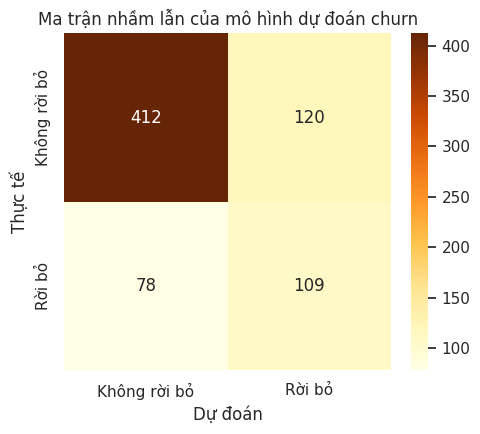

In [ ]:
cm = confusion_matrix(yC_test, predC)
plt.figure(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap="YlOrBr", xticklabels=['Không rời bỏ','Rời bỏ'], yticklabels=['Không rời bỏ','Rời bỏ'])
plt.xlabel("Dự đoán"); plt.ylabel("Thực tế"); plt.title("Ma trận nhầm lẫn của mô hình dự đoán churn")
plt.tight_layout(); plt.show()


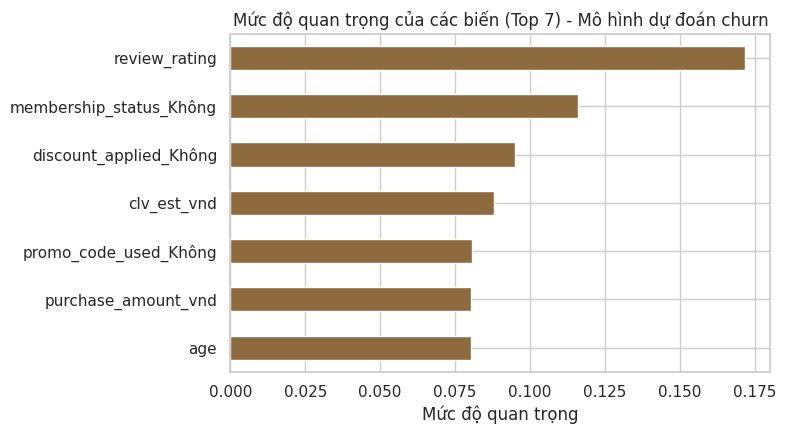

,0
review_rating,0.171685
membership_status_Không,0.116143
discount_applied_Không,0.094881
clv_est_vnd,0.088008
promo_code_used_Không,0.080641
purchase_amount_vnd,0.080348
age,0.080249


In [ ]:
importances = pd.Series(clf.feature_importances_, index=XC.columns).sort_values(ascending=False).head(7)
plt.figure(figsize=(8, 4.5))
importances.sort_values().plot(kind='barh', color="#8e6b3f")
plt.title("Mức độ quan trọng của các biến (Top 7) - Mô hình dự đoán churn")
plt.xlabel("Mức độ quan trọng")
plt.tight_layout(); plt.show()

importances

9. Trả lời các câu hỏi kinh doanh

In [ ]:
df['churn_proba'] = clf.predict_proba(XC)[:, 1]

print("Câu hỏi 1 - Có bao nhiêu nhóm khách hàng khác nhau?")
print(cluster_summary[['so_luong', 'ty_le_%', 'nhom']].sort_values('ty_le_%', ascending=False))

print("\nCâu hỏi 2 - Khách hàng nào có giá trị cao nhất? (Top 5 theo CLV)")
print(top5_vip)

print("\nCâu hỏi 3 - Khách hàng nào có nguy cơ rời bỏ? (Top 5 ưu tiên giữ chân)")
priority = df[df['cluster_name'] == "Khách hàng có nguy cơ rời bỏ"].sort_values('churn_proba', ascending=False).head(5)[
    ['customer_id', 'clv_est_vnd', 'churn_proba', 'previous_purchases', 'review_rating']]
print(priority)

Câu hỏi 1 - Có bao nhiêu nhóm khách hàng khác nhau?
         so_luong  ty_le_%                               nhom
cluster                                                      
0            1330     37.0         Khách hàng phổ thông / mới
3            1233     34.3             Khách hàng trung thành
2             631     17.6       Khách hàng có nguy cơ rời bỏ
1             399     11.1  Khách hàng VIP (giá trị cao nhất)

Câu hỏi 2 - Khách hàng nào có giá trị cao nhất? (Top 5 theo CLV)
      customer_id  clv_est_vnd  monetary_est_vnd  previous_purchases
2729         2736  428590298.0       368268000.0                  30
14             15  358309923.0       346026000.0                  30
836           840  345711565.0       315776000.0                  27
121           122  334954754.0       340332000.0                  30
2997         3004  328013414.0       278544000.0                  19

Câu hỏi 3 - Khách hàng nào có nguy cơ rời bỏ? (Top 5 ưu tiên giữ chân)
      customer_id  clv_e

In [ ]:
# (Tùy chọn) Xuất file dữ liệu đã xử lý & gắn nhãn cụm/churn để nộp kèm báo cáo
df.to_csv("trang_suc_processed_final.csv", index=False, encoding='utf-8-sig')
from google.colab import files
files.download("trang_suc_processed_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>